# Exempelnotebook: datahantering i ESS (Sverige, omgång 11)

Här går vi igenom de databeredningssteg som projektuppgiften bygger på. Först läser vi in data från European Social Survey (ESS), tar bort koder för saknade värden, dikotomiserar en svarsvariabel och ställer upp tabellen över gruppstorlekar före och efter rensning (detta är det ni gör i A1 med ett annat land, svarsvariabe och gruppindelning). Sedan delar vi in intervjudatumen i veckor (B1b) och ritar en intervallplott, det vill säga flera skattningar med sina intervall längs en gemensam axel.

Exemplet använder Sverige. Sverige är inte ett tillgängligt val i del A, så tabellerna nedan kan inte återanvändas i någon rapport. Anpassa i stället koden till ditt eget land och dina egna variabler.

Hur du registrerar dig och laddar ned data beskrivs i dataguiden. Här har vi laddat ned hela omgång 11 för Sverige, med alla variabler, i CSV-format. Filen heter `ESS11_SE.csv` och kan laddas ned från Canvas.

Vi börjar med att importera de paket som behövs. Notera att vi här använder paketet Pandas för att hantera och analysera datamängder. Detta är ett mycket kraftfullt paket men kan vara svårt att använda om man inte är bekant med det. Ett mål med denna notebook är att visa hur vissa standardoperationer utförs i Pandas så att ni kan fokusera på beräkningarna som krävs för analys och inferens på datamängden.

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import pandas as pd

## Data

Vi läser in filen med `pd.read_csv`. Resultatet är en *dataram* (`DataFrame`), en tabell med en rad per respondent och en kolumn per variabel. Förutom kolumnerna har varje rad ett *index* som identifierar raden. Man kan tänka sig indexet som en speciell kolumn. Den innehåller inte någon data, men används bara för identifikation. Detta index följer sedan med när man gör olika operationer på dataramen.

In [2]:
df = pd.read_csv("ESS11_SE.csv")

# shape ger (antal rader, antal kolumner).
print(f"Antal respondenter: {df.shape[0]}")
print(f"Antal variabler: {df.shape[1]}")

Antal respondenter: 1230
Antal variabler: 691


Metoden `info()` ger en översikt över dataramen. Med så här många kolumner visas bara en sammanfattning av kolumntyperna.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1230 entries, 0 to 1229
Columns: 691 entries, name to psu
dtypes: float64(262), int64(408), object(21)
memory usage: 6.5+ MB


Vi tittar på de första raderna för de variabler vi ska använda med hjälp av metoden `head()` som visar de fem första raderna. Notera att index för varje rad syns längst till vänster.

In [4]:
columns = ["idno", "ppltrst", "sgnptit", "region", "agea", "domicil", "inwds", "inwde"]

df[columns].head()

,idno,ppltrst,sgnptit,region,agea,domicil,inwds,inwde
0,50036,5,1,SE22,61,3,2023-07-31 09:51:17,2023-07-31 11:02:05
1,50047,6,2,SE23,33,2,2023-05-22 14:01:10,2023-05-22 15:12:40
2,50069,8,1,SE22,40,3,2023-04-14 14:38:56,2023-04-14 16:21:29
3,50093,5,1,SE12,37,1,2023-06-09 13:59:21,2023-06-09 15:12:04
4,50110,4,2,SE22,64,3,2023-05-17 10:44:27,2023-05-17 11:51:27


## Saknade värden i svarsvariabeln

Vi använder två svarsvariabler som exempel: `ppltrst` (man kan lita på de flesta människor, 0–10) och `sgnptit` (skrivit under en namninsamling de senaste 12 månaderna, 1 = ja, 2 = nej). Vi kan extrahera individuella kolumner från dataramen genom `df["column"]` och får då en *dataserie*, vilket är en indexerad sekvens av värden från kolumnen. (Notera att detta skiljer sig från `df[["column"]]` som skapar en dataram med endast en kolumn.)

In [5]:
type(df["ppltrst"])

pandas.core.series.Series

Innan vi gör något annat med en variabel tittar vi på vilka värden som antas.

In [6]:
# value_counts() räknar hur många gånger varje värde förekommer (ett typ av histogram).
# sort_index() sorterar resultatet efter värdet i stället för efter antalet.
df["ppltrst"].value_counts().sort_index()

ppltrst
0      13
1      12
2      33
3      79
4      77
5     180
6     171
7     289
8     275
9      74
10     26
88      1
Name: count, dtype: int64

Värdena 0–10 är riktiga svar, men vi har också värdet 88. Enligt kodboken betyder 77 att respondenten vägrade svara, 88 att hen inte vet och 99 att svar saknas. Om vi inte tar bort dessa koder räknas 88 som ett mycket högt förtroende, och till exempel ett medelvärde blir fel. Vi skapar en *mask*, en kolumn med `True` för varje respondent med ett giltigt svar.

In [7]:
# Koder för saknade värden enligt kodboken: 77 vägrat, 88 vet ej, 99 inget svar.
ppltrst_missing_codes = [77, 88, 99]

# isin() ger True för rader vars värde finns i listan, och ~ inverterar masken.
valid_ppltrst = ~df["ppltrst"].isin(ppltrst_missing_codes)

print(f"Giltiga svar på ppltrst: {valid_ppltrst.sum()}")
print(f"Borttagna (kod för saknat värde): {(~valid_ppltrst).sum()}")

Giltiga svar på ppltrst: 1229
Borttagna (kod för saknat värde): 1


För `sgnptit` är koderna ensiffriga, eftersom variabeln bara har ett fåtal svarsalternativ. Koderna för saknade värden är således också ensiffriga. Generellt så gäller det alltså att koderna för saknade värden varierar mellan variabler och måste slås upp i kodboken för varje variabel.

In [8]:
df["sgnptit"].value_counts().sort_index()

sgnptit
1    393
2    829
8      8
Name: count, dtype: int64

In [9]:
# Koder för saknade värden enligt kodboken: 7 vägrat, 8 vet ej, 9 inget svar.
sgnptit_missing_codes = [7, 8, 9]

valid_sgnptit = ~df["sgnptit"].isin(sgnptit_missing_codes)

print(f"Giltiga svar på sgnptit: {valid_sgnptit.sum()}")
print(f"Borttagna (kod för saknat värde): {(~valid_sgnptit).sum()}")

Giltiga svar på sgnptit: 1222
Borttagna (kod för saknat värde): 8


## Saknade värden i grupperingsvariabeln

Samma kontroll behövs för grupperingsvariabeln. Vi använder `region` som grupperingsvariabel i resten av notebooken. Värdena är regionkoder, och kodboken anger vad de står för.

In [10]:
df["region"].value_counts().sort_index()

region
SE11    237
SE12    194
SE21    104
SE22    184
SE23    250
SE31    105
SE32     53
SE33    103
Name: count, dtype: int64

I den svenska filen förekommer inga koder för saknade värden i `region`, och `isna()` visar att inga värden saknas helt (dvs. vi har inga värden som anges som `None` eller `np.NaN`). Kontrollera detta för ditt eget land. Kodboken ger regionernas namn, som vi lägger i en ordbok för att kunna använda dem i tabeller och figurer.

In [11]:
# isna() ger True där ett värde saknas helt i filen (NaN).
print(f"Saknade värden i region: {df['region'].isna().sum()}")

# Regionnamn enligt kodboken.
region_names = {
    "SE11": "Stockholm",
    "SE12": "Östra Mellansverige",
    "SE21": "Småland med öarna",
    "SE22": "Sydsverige",
    "SE23": "Västsverige",
    "SE31": "Norra Mellansverige",
    "SE32": "Mellersta Norrland",
    "SE33": "Övre Norrland",
}

Saknade värden i region: 0


För de andra grupperingsvariablerna ser det annorlunda ut. `domicil` har koderna 7, 8 och 9 för saknade värden, och i den svenska filen förekommer koden 8 (vet ej).

In [12]:
df["domicil"].value_counts().sort_index()

domicil
1    187
2    272
3    423
4    207
5    139
8      2
Name: count, dtype: int64

### Åldersklasser

Åldersindelningen bygger på `agea`, där kodboken anger 999 för saknad ålder. Den svenska filen har ingen sådan kod, men vi tar ändå bort den, så att koden fungerar för andra länder.

Vi delar in åldrarna i de sju fasta åldersklasserna med `pd.cut`. Argumentet `bins` anger klassgränserna och `right=False` gör att varje klass omfattar sin nedre gräns men inte sin övre, så att till exempel 25 hamnar i klassen 25–34. ESS intervjuar bara personer som är 15 år eller äldre, så den absoluta nedre gränsen är 15. Den sista klassen saknar övre gräns, vilket vi anger med `np.inf`.

Notera att vi här lägger till en ny kolumn, `age_band` i den existerande ramen. De flesta operationer i Canvas håller reda på index för varje rad, vilket gör att denna typ av tilldelning fungerar utan problem (dvs. man behöver inte ha explicit koll på ordningen).

In [13]:
# 999 betyder att åldern saknas. Vi sätter sådana värden till NaN med where(),
# som behåller värdena där villkoret är sant och ersätter övriga med NaN.
ages = df["agea"].where(df["agea"] != 999)

age_bins = [15, 25, 35, 45, 55, 65, 75, np.inf]
age_labels = ["15–24", "25–34", "35–44", "45–54", "55–64", "65–74", "75+"]

df["age_band"] = pd.cut(ages, bins=age_bins, labels=age_labels, right=False)

print(f"Saknad ålder: {df['age_band'].isna().sum()}")
df["age_band"].value_counts().sort_index()

Saknad ålder: 0


age_band
15–24    101
25–34    140
35–44    164
45–54    185
55–64    222
65–74    209
75+      209
Name: count, dtype: int64

## Tröskelvärde och dikotomisering

I projektet behandlas svaret som binärt. Vi väljer tröskelvärdet 7 för `ppltrst`, så att ett svar på 7 eller högre räknas som ett positivt svar. För `sgnptit` är svaret ja (1) ett positivt svar.

Vi skapar först *landets delstickprov efter rensning*, det vill säga de respondenter som har giltiga svar på både svarsvariabeln och grupperingsvariabeln. Från och med nu använder vi `ppltrst` som svarsvariabel. Masker kombineras med `&` (och), och varje villkor ska stå inom parentes.

In [14]:
threshold = 7

valid_region = df["region"].notna()
keep = valid_ppltrst & valid_region

# copy() skapar en fristående dataram, så att nya kolumner inte påverkar df.
df_clean = df.loc[keep].copy()

# En jämförelse ger True eller False, som vi sparar som heltalen 1 och 0.
df_clean["positive"] = (df_clean["ppltrst"] >= threshold).astype(int)

# Motsvarande dikotomisering av sgnptit, där 1 betyder ja.
sgnptit_positive = (df.loc[valid_sgnptit, "sgnptit"] == 1).astype(int)

print(f"Respondenter efter rensning: {len(df_clean)}")
print(f"Andel ja på sgnptit bland giltiga svar: {sgnptit_positive.mean():.3f}")

Respondenter efter rensning: 1229
Andel ja på sgnptit bland giltiga svar: 0.322


Det fjärde kravet i A1 gäller andelen positiva svar i hela landets delstickprov. Den andelen säger inget om vilken av två grupper som ligger högst och får därför beräknas innan grupperna väljs.

In [15]:
base_rate = df_clean["positive"].mean()

print(f"Andel positiva svar i hela delstickprovet: {base_rate:.3f}")

Andel positiva svar i hela delstickprovet: 0.540


## Gruppstorlekar före och efter rensning

Nu ställer vi upp tabellen som A1(a) efterfrågar. Vi räknar antalet respondenter per region i hela filen och i det rensade delstickprovet. Metoden `groupby` delar in dataramen efter värdet i en kolumn, och `size()` räknar raderna i varje grupp. Detta skapar en ny typ av dataram, *grupperade dataramar*, som inte längre innehåller indviduella rader, men *grupper* av rader (se <https://pandas.pydata.org/pandas-docs/stable/user_guide/groupby.html> för mer info).

Om grupperingsvariabeln hade haft saknade värden skulle de respondenterna inte synas i `groupby`. Deras antal redovisas då på en egen rad.

In [16]:
n_before = df.groupby("region").size()
n_after = df_clean.groupby("region").size()

# Vi bygger en ny dataram med en rad per region. reindex() ser till att
# regioner som försvunnit helt vid rensningen får antalet 0.
group_sizes = pd.DataFrame({
    "Region": [region_names[r] for r in n_before.index],
    "Före rensning": n_before,
    "Efter rensning": n_after.reindex(n_before.index, fill_value=0),
})
group_sizes["Borttagna"] = group_sizes["Före rensning"] - group_sizes["Efter rensning"]
group_sizes.index.name = "Regionkod"

group_sizes

,Region,Före rensning,Efter rensning,Borttagna
Regionkod,,,,
SE11,Stockholm,237,237,0
SE12,Östra Mellansverige,194,194,0
SE21,Småland med öarna,104,104,0
SE22,Sydsverige,184,184,0
SE23,Västsverige,250,249,1
SE31,Norra Mellansverige,105,105,0
SE32,Mellersta Norrland,53,53,0
SE33,Övre Norrland,103,103,0


In [17]:
print(f"Totalt före rensning: {len(df)}")
print(f"Totalt efter rensning: {len(df_clean)}")
print(f"Borttagna för saknat svar på ppltrst: {(~valid_ppltrst).sum()}")
print(f"Borttagna för saknad region: {(~valid_region).sum()}")

Totalt före rensning: 1230
Totalt efter rensning: 1229
Borttagna för saknat svar på ppltrst: 1
Borttagna för saknad region: 0


Med tabellen kan vi kontrollera kraven i A1. Som illustration väljer vi två grupper enbart utifrån deras storlek, Stockholm (`SE11`) och Övre Norrland (`SE33`). I projektet är det här du förregistrerar ditt val, *innan* du beräknar andelen positiva svar i någon grupp.

In [18]:
group_j = "SE11"
group_k = "SE33"

n_j = n_after[group_j]
n_k = n_after[group_k]
n_min = min(n_j, n_k)

print(f"Minst 1000 giltiga svar: {len(df_clean)} ({len(df_clean) >= 1000})")
print(f"Minst 5 icke-tomma grupper: {len(n_after)} ({len(n_after) >= 5})")
print(f"Minst 30 i varje vald grupp: {n_j} och {n_k} ({n_min >= 30})")
print(f"Andelen mellan 0.15 och 0.85: {base_rate:.3f} ({0.15 <= base_rate <= 0.85})")
print(f"Andelen gånger minsta gruppen minst 10: {base_rate * n_min:.1f} "
      f"({base_rate * n_min >= 10})")

Minst 1000 giltiga svar: 1229 (True)
Minst 5 icke-tomma grupper: 8 (True)
Minst 30 i varje vald grupp: 237 och 103 (True)
Andelen mellan 0.15 och 0.85: 0.540 (True)
Andelen gånger minsta gruppen minst 10: 55.6 (True)


## Intervjudatum

I omgång 11 finns intervjuns start och slut som tidsstämplar i `inwds` och `inwde`. I omgång 3–9, som händelserna i del B hör till, finns i stället ett datum uppdelat i dag, månad och år (se dataguiden). För att visa hur de äldre variablerna hanteras gör vi om tidsstämplarna till den äldre formen och arbetar sedan bara med den.

Först omvandlar vi textsträngarna till tidsstämplar med `pd.to_datetime`. Detta gör det enklare att beräkna olika saker från datumen. Vi kan exempelvis se när fältperioden började och slutade.

In [19]:
start_times = pd.to_datetime(df["inwds"])
end_times = pd.to_datetime(df["inwde"])

print(f"Första intervjun: {start_times.min()}")
print(f"Sista intervjun: {end_times.max()}")
print(f"Saknade starttider: {start_times.isna().sum()}")

Första intervjun: 2023-03-13 12:01:17
Sista intervjun: 2023-12-08 14:17:06
Saknade starttider: 0


### Omvandling till den äldre formen

Via `.dt` kommer vi åt delarna av en tidsstämpel. Vi skapar variablerna `inwdds`, `inwmms` och `inwyys` (start) och `inwdde`, `inwmme` och `inwyye` (slut) med samma namn som i de äldre omgångarna. I de äldre filerna är ett saknat datum kodat med en kod för saknat värde, inte som ett tomt fält. Vi efterliknar det genom att ersätta saknade delar med 99 för dag och månad och 9999 för år. I den svenska filen saknas inga datum, så ersättningen påverkar inget här.

In [20]:
# fillna() ersätter saknade värden. Resultatet görs om till heltal med astype(int).
df["inwdds"] = start_times.dt.day.fillna(99).astype(int)
df["inwmms"] = start_times.dt.month.fillna(99).astype(int)
df["inwyys"] = start_times.dt.year.fillna(9999).astype(int)

df["inwdde"] = end_times.dt.day.fillna(99).astype(int)
df["inwmme"] = end_times.dt.month.fillna(99).astype(int)
df["inwyye"] = end_times.dt.year.fillna(9999).astype(int)

df[["inwdds", "inwmms", "inwyys", "inwdde", "inwmme", "inwyye"]].head()

,inwdds,inwmms,inwyys,inwdde,inwmme,inwyye
0,31,7,2023,31,7,2023
1,22,5,2023,22,5,2023
2,14,4,2023,14,4,2023
3,9,6,2023,9,6,2023
4,17,5,2023,17,5,2023


### Datum från dag, månad och år

Från och med här använder vi bara de sex variablerna ovan, precis som för en fil från omgång 3–9. Först tar vi bort koderna för saknade värden. I kodböckerna för de äldre omgångarna betyder 99 att dag eller månad saknas och 9999 att året saknas. Vi ersätter dem med `NaN` (metoden `where` utan andra argument sätter värden till `NaN` när första argumentet är falskt).

In [21]:
# Kolumnerna för start respektive slut, i ordningen dag, månad, år.
start_columns = ["inwdds", "inwmms", "inwyys"]
end_columns = ["inwdde", "inwmme", "inwyye"]

# Kod för saknat värde per kolumn enligt kodboken.
date_missing_codes = {
    "inwdds": 99, "inwmms": 99, "inwyys": 9999,
    "inwdde": 99, "inwmme": 99, "inwyye": 9999,
}

date_parts = df[start_columns + end_columns].copy()
for column, missing_code in date_missing_codes.items():
    date_parts[column] = date_parts[column].where(date_parts[column] != missing_code)

# any(axis=1) ger True för rader där minst en av kolumnerna är sann.
start_coded_missing = date_parts[start_columns].isna().any(axis=1)
end_coded_missing = date_parts[end_columns].isna().any(axis=1)

print(f"Startdatum med kod för saknat värde: {start_coded_missing.sum()}")
print(f"Slutdatum med kod för saknat värde: {end_coded_missing.sum()}")

Startdatum med kod för saknat värde: 0
Slutdatum med kod för saknat värde: 0


Sedan sätter vi ihop delarna till datum. Om `pd.to_datetime` får en dataram med kolumnerna `year`, `month` och `day` bildar den ett datum per rad. Med `errors="coerce"` blir en rad som inte ger ett giltigt datum ett saknat datum (`NaT`) i stället för ett fel. Det gäller raderna med `NaN` från förra steget, men också datum som inte finns i kalendern. (Sådana förekommer tyvärr i ESS-filerna, till exempel 29 februari ett år som inte är skottår.) Vi räknar dem för sig, eftersom de är fel i data och inte koder, och redovisar hur många de är. Vi behandlar dem som saknade.

Konventionen i del B är att en intervju dateras med startdatum, eller med slutdatum om startdatum saknas. Metoden `fillna` fyller i de saknade startdatumen med slutdatumen.

In [22]:
# rename() byter kolumnnamnen till de namn som pd.to_datetime kräver.
start_dates = pd.to_datetime(
    date_parts[start_columns].rename(columns={"inwdds": "day", "inwmms": "month", "inwyys": "year"}),
    errors="coerce",
)
end_dates = pd.to_datetime(
    date_parts[end_columns].rename(columns={"inwdde": "day", "inwmme": "month", "inwyye": "year"}),
    errors="coerce",
)

start_invalid = start_dates.isna() & ~start_coded_missing
end_invalid = end_dates.isna() & ~end_coded_missing

print(f"Ogiltiga startdatum (inte koder): {start_invalid.sum()}")
print(f"Ogiltiga slutdatum (inte koder): {end_invalid.sum()}")

Ogiltiga startdatum (inte koder): 0
Ogiltiga slutdatum (inte koder): 0


In [23]:
df["interview_date"] = start_dates.fillna(end_dates)

print(f"Saknat startdatum: {start_dates.isna().sum()}")
print(f"Saknat startdatum men giltigt slutdatum: {(start_dates.isna() & end_dates.notna()).sum()}")
print(f"Saknat datum efter komplettering: {df['interview_date'].isna().sum()}")

Saknat startdatum: 0
Saknat startdatum men giltigt slutdatum: 0
Saknat datum efter komplettering: 0


Datumen saknar klockslag, vilket är som det ska. Fönstren i del B räknas i hela kalenderdagar, och en intervju som började 23.59 hör till den dagen.

Vi för över datumen till det rensade delstickprovet. Eftersom `df_clean` skapades från `df` har raderna samma index (ej att förväxla med radnumret), och Pandas matchar värdena efter index.

In [24]:
df_clean["interview_date"] = df["interview_date"]

df_clean[["idno", "interview_date", "ppltrst", "positive"]].head()

,idno,interview_date,ppltrst,positive
0,50036,2023-07-31,5,0
1,50047,2023-05-22,6,0
2,50069,2023-04-14,8,1
3,50093,2023-06-09,5,0
4,50110,2023-05-17,4,0


## Veckoindelning

Vi delar in intervjudatumen i kalenderveckor med `dt.to_period("W")`, som kodar varje vecka med datumen för måndagen och söndagen den veckan. Vi använder inte veckonumren (vecka 1–52) eftersom de börjar om vid årsskiftet, så en fältperiod som sträcker sig över nyår skulle få vecka 52 och vecka 1 i fel ordning.

Därefter grupperar vi efter vecka och beräknar antalet intervjuer och andelen positiva svar. Med `agg` kan vi beräkna flera storheter per grupp på en gång. På vanliga dataramer beräknar den statistikor över hela dataramen, men på grupperade dataramar (som fås genom `groupby`) så beräknas statistikorna per grupp.

In [25]:
df_clean["week"] = df_clean["interview_date"].dt.to_period("W")

# agg() tar par av (kolumn, funktion). Här räknar vi antalet rader och
# medelvärdet av 0/1-kolumnen, som är andelen positiva svar.
weekly = df_clean.groupby("week").agg(
    n=("positive", "size"),
    share=("positive", "mean"),
)

weekly.head()

,n,share
week,,
2023-03-13/2023-03-19,20,0.400000
2023-03-20/2023-03-26,62,0.516129
2023-03-27/2023-04-02,78,0.589744
2023-04-03/2023-04-09,50,0.480000
2023-04-10/2023-04-16,62,0.580645


Veckor utan intervjuer finns inte med i `weekly`. För att de ska synas som luckor i figuren fyller vi ut tabellen med alla veckor under fältperioden. `pd.period_range` ger en följd av veckor, och `reindex` lägger till de saknade veckorna med `NaN`-värden. Vi använder sedan `fillna` för att sätta `n` för dessa veckor till 0.

In [26]:
all_weeks = pd.period_range(weekly.index.min(), weekly.index.max(), freq="W")

weekly = weekly.reindex(all_weeks)
weekly["n"] = weekly["n"].fillna(0).astype(int)

print(f"Antal veckor i fältperioden: {len(weekly)}")
print(f"Veckor utan intervjuer: {(weekly['n'] == 0).sum()}")

Antal veckor i fältperioden: 39
Veckor utan intervjuer: 0


Vi ritar andelen positiva svar per vecka i en övre panel och antalet intervjuer per vecka i en nedre panel med samma tidsaxel. Varje vecka ritas vid sin mittpunkt, torsdagen. Andelen i en vecka med få intervjuer är mycket osäker, vilket den nedre panelen gör synligt. I del B markerar du också händelsedatumet, till exempel med `plt.axvline`.

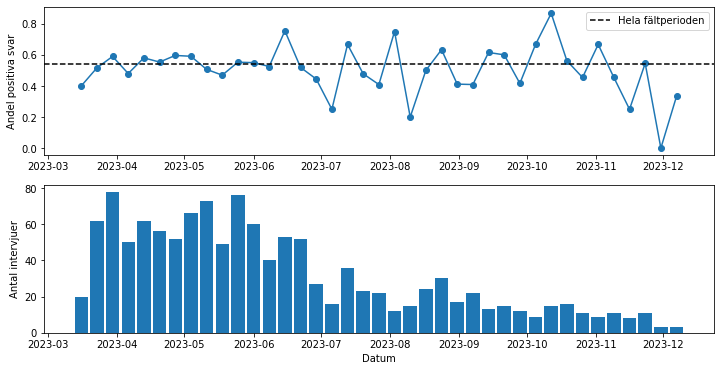

In [27]:
# start_time ger veckans första dag (måndag) som tidsstämpel, vilket matplotlib
# kan rita. Vi flyttar fram tre dagar till veckans mittpunkt.
week_mids = weekly.index.start_time + pd.Timedelta(days=3)

plt.figure(figsize=(12, 6))

ax_top = plt.subplot(2, 1, 1)
# Matplotlib hanterar datetime-objekt på ett naturligt sätt.
plt.plot(week_mids, weekly["share"], marker="o")
plt.axhline(base_rate, color="black", linestyle="--", label="Hela fältperioden")
plt.ylabel("Andel positiva svar")
plt.legend()

# sharex=ax_top ger den nedre panelen samma tidsaxel som den övre.
plt.subplot(2, 1, 2, sharex=ax_top)
# width anges i dagar. Staplarna täcker nästan hela veckan.
plt.bar(week_mids, weekly["n"], width=6)
plt.xlabel("Datum")
plt.ylabel("Antal intervjuer")

plt.show()

## Intervallplott

Till sist ritar vi flera skattningar med sina intervall längs en gemensam axel. Samma sätt att rita används i A5(c), A8(a) och B4. Notera att i projektet beräknar du andelarna per grupp först efter att du har förregistrerat dina val. Här gör vi det bara för att visa hur figuren ritas.

För varje region $j$ beräknar vi andelen positiva svar $\hat p_j = x_j / n_j$ och Waldintervallet med konfidensgrad 95%,
$$
\hat p_j \pm \lambda_{0.025} \sqrt{\frac{\hat p_j (1 - \hat p_j)}{n_j}},
$$
där $\lambda_{0.025}$ är den kvantil för standardnormalfördelningen som överskrids med sannolikheten 0.025.

In [28]:
x_counts = df_clean.groupby("region")["positive"].sum()
n_counts = df_clean.groupby("region")["positive"].size()

p_ests = x_counts / n_counts

# λ_0.025 i kursens beteckning, ungefär 1.96.
lambda_q = stats.norm.ppf(0.975)
half_widths = lambda_q * np.sqrt(p_ests * (1 - p_ests) / n_counts)

intervals = pd.DataFrame({
    "Region": [region_names[r] for r in p_ests.index],
    "n": n_counts,
    "x": x_counts,
    "Andel": p_ests.round(3),
    "Nedre": (p_ests - half_widths).round(3),
    "Övre": (p_ests + half_widths).round(3),
})
intervals.index.name = "Regionkod"

intervals

,Region,n,x,Andel,Nedre,Övre
Regionkod,,,,,,
SE11,Stockholm,237,129,0.544,0.481,0.608
SE12,Östra Mellansverige,194,100,0.515,0.445,0.586
SE21,Småland med öarna,104,61,0.587,0.492,0.681
SE22,Sydsverige,184,87,0.473,0.401,0.545
SE23,Västsverige,249,132,0.530,0.468,0.592
SE31,Norra Mellansverige,105,60,0.571,0.477,0.666
SE32,Mellersta Norrland,53,34,0.642,0.512,0.771
SE33,Övre Norrland,103,61,0.592,0.497,0.687


Funktionen `plt.errorbar` ritar en punkt med ett intervall runt varje skattning. Argumentet `yerr` anger avståndet från punkten till intervallets ändar. Grupperna placeras på heltalspositionerna $0, 1, \ldots, m - 1$ och får sina namn med `plt.xticks`. Om ett intervall inte är symmetriskt, till exempel ett kredibilitetsintervall från kvantiler, anges `yerr` som en matris med två rader: avståndet ned till den nedre gränsen och avståndet upp till den övre.

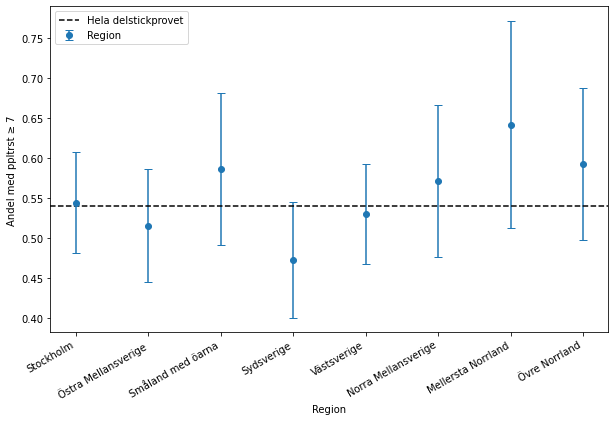

In [29]:
positions = np.arange(len(p_ests))

plt.figure(figsize=(10, 6))
plt.errorbar(positions, p_ests, yerr=half_widths, fmt="o", capsize=4, label="Region")
plt.axhline(base_rate, color="black", linestyle="--", label="Hela delstickprovet")
plt.xticks(positions, intervals["Region"], rotation=30, ha="right")
plt.xlabel("Region")
plt.ylabel(f"Andel med ppltrst ≥ {threshold}")
plt.legend()
plt.show()

## Att anpassa till ditt projekt

- Byt filnamn, svarsvariabel, tröskelvärde och grupperingsvariabel. Slå upp koderna för saknade värden i kodboken för varje variabel du använder, även grupperingsvariabeln.
- Redovisa tabellen över gruppstorlekar och vad du tog bort och varför. Välj och förregistrera dina två grupper innan du beräknar några andelar per grupp.
- I del B kommer intervjudatumen direkt från variablerna för dag, månad och år, så omvandlingen från tidsstämplar behövs inte. Stegen från *Datum från dag, månad och år* och framåt gäller däremot oförändrade.
- Intervallplotten fungerar för alla skattningar med intervall, oavsett om intervallen är konfidensintervall eller kredibilitetsintervall.